<a href="https://colab.research.google.com/github/dang710206/Baitap-AI-/blob/main/Baitap_Map_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#BT1
import folium

# Tạo bản đồ trung tâm tại UEH
m = folium.Map(location=[10.7842, 106.7005],
               zoom_start=14)

# Thêm lớp Tile khác để đẹp hơn (tùy chọn)
folium.TileLayer("CartoDB positron").add_to(m)

# Danh sách các điểm (bạn có thể thêm nhiều hơn)
locations = [
    {"name": "UEH Cơ sở A (Trụ sở chính)",
     "lat":10.783137700704238, "lon": 106.69466765857163,
     "popup": "<b>UEH - Đại học Kinh tế TP.HCM</b><br>59C Nguyễn Đình Chiểu, Phường 6, Xuân Hòa, Hồ Chí Minh"},

    {"name": "Vincom Center Đồng Khởi",
     "lat":10.777870005988708, "lon":  106.70162740826221,
     "popup": "<b>Vincom Center Đồng Khởi</b><br>72 Lê Thánh Tôn, Sài Gòn, Hồ Chí Minh"},

    {"name": "Bệnh viện Nguyễn Tri Phương",
     "lat":10.755381832816969, "lon":  106.67039156426247,
     "popup": "<b>Bệnh viện Nguyễn Tri Phương</b><br>468 Nguyễn Trãi, Phường 7, An Đông, Hồ Chí Minh"},

    {"name": "Katinat - Bến Bạch Đằng",
     "lat": 10.775161334082885, "lon": 106.7070887283867,
     "popup": "<b>Katinat - Bến Bạch Đằng</b><br>Ben Thanh, Ho Chi Minh"},

    {"name": "Dinh Độc Lập",
     "lat": 10.777254032939235, "lon": 106.69524768573173,
     "popup": "<b>Dinh Độc Lập</b><br>10B Tôn Đức Thắng, Sài Gòn, Hồ Chí Minh"},

    {"name": "Vạn Hạnh Mall",
     "lat": 10.77074342661742, "lon":  106.66989060826211,
     "popup": "<b>Vạn Hạnh Mall</b><br>11 Sư Vạn Hạnh, Hòa Hưng, Hồ Chí Minh"},

]

# Thêm marker cho từng điểm
for loc in locations:
    color = "red" if "UEH" in loc["name"] else "blue"

    folium.Marker(
        location=[loc["lat"], loc["lon"]],
        popup=folium.Popup(loc["popup"], max_width=300),
        tooltip=loc["name"],
        icon=folium.Icon(color=color, icon="info-sign")
    ).add_to(m)

m

In [ ]:
#Bt2
import folium
from folium import plugins
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time

# Khởi tạo geocoder (GeoPy)
geolocator = Nominatim(user_agent="ueh_map_project")

# Điểm trung tâm: UEH Cơ sở A
center_lat, center_lon = 10.783289041601115, 106.69467159024265
print(f"Điểm trung tâm UEH: {center_lat:.6f}, {center_lon:.6f}")

# List địa điểm
places = [
    "Nhà thờ Đức bà",
    "Bảo tàng Thành Phố Hồ Chí Minh",
    "Dinh Độc Lập",
    "Bệnh viện Nhi Đồng 1",
    "Sân bay quốc tế Tân Sơn Nhất",
    "Thảo Cầm Viên",
    "Vincom Center Đồng Khởi",
    "Vạn Hạnh Mall",
    "Bến xe Sài Gòn",
    "Phố đi bộ Nguyễn Huệ"
]

#Folium
m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles="OpenStreetMap")

# Thêm marker UEH
folium.Marker(
    location=[center_lat, center_lon],
    popup="<b>Điểm trung tâm: UEH Cơ sở A</b>",
    tooltip="UEH cơ sở A",
    icon=folium.Icon(color="red", icon="university", prefix="fa")
).add_to(m)

# Xử lý từng điểm
for place in places:
    try:
        location = geolocator.geocode(place, timeout=10)
        if location:
            lat, lon = location.latitude, location.longitude

            # Tính khoảng cách
            distance = geodesic((center_lat, center_lon), (lat, lon)).kilometers

            # Thêm marker
            popup_html = f"""
            <b>{place}</b><br>
            Tọa độ: {lat:.5f}, {lon:.5f}<br>
            Khoảng cách đến UEH: <b>{distance:.2f} km</b>
            """

            folium.Marker(
                location=[lat, lon],
                popup=folium.Popup(popup_html, max_width=300),
                tooltip=f"{place.split(',')[0]} ({distance:.1f} km)",
                icon=folium.Icon(color="blue", icon="info-sign")
            ).add_to(m)

            # Vẽ đường thẳng
            folium.PolyLine(
                locations=[[center_lat, center_lon], [lat, lon]],
                color="gray",
                weight=2,
                opacity=0.7,
                tooltip=f"Khoảng cách: {distance:.2f} km"
            ).add_to(m)

            print(f"✓ {place} → {distance:.2f} km")
        else:
            print(f"✗ Không tìm được: {place}")

        time.sleep(1)  # Tránh bị chặn khi gọi API quá nhanh

    except Exception as e:
        print(f"Lỗi với {place}: {e}")

m

Điểm trung tâm UEH: 10.783289, 106.694672
✓ Nhà thờ Đức bà → 0.66 km
✓ Bảo tàng Thành Phố Hồ Chí Minh → 0.98 km
✓ Dinh Độc Lập → 0.70 km
✓ Bệnh viện Nhi Đồng 1 → 3.09 km
✓ Sân bay quốc tế Tân Sơn Nhất → 5.69 km
✓ Thảo Cầm Viên → 1.29 km
✓ Vincom Center Đồng Khởi → 0.97 km
✓ Vạn Hạnh Mall → 3.09 km
✓ Bến xe Sài Gòn → 1.82 km
✓ Phố đi bộ Nguyễn Huệ → 1.06 km


In [ ]:
#bt3
import folium
from folium.plugins import HeatMap
import pandas as pd
import numpy as np

# Tâm khu vực
center_lat, center_lon = 10.777517832455732, 106.69534640139356

np.random.seed(42)  # để kết quả có thể tái lập

# Tạo 3 cụm khách hàng với mật độ khác nhau
data = []

# Cụm 1: Trung tâm
for _ in range(120):
    lat = center_lat + np.random.normal(0, 0.005)
    lon = center_lon + np.random.normal(0, 0.005)
    data.append([lat, lon])

# Cụm 2:
for _ in range(50):
    lat = center_lat + np.random.normal(0, 0.03)
    lon = center_lon + np.random.normal(0, 0.03)
    data.append([lat, lon])

# Cụm 3: Phía Tây
for _ in range(30):
    lat = center_lat - np.random.normal(0.018, 0.004)
    lon = center_lon - np.random.normal(0.025, 0.004)
    data.append([lat, lon])

# Thêm một số điểm rải rác (nhiễu) để tạo vùng thưa
for _ in range(30):
    lat = center_lat + np.random.uniform(-0.05, 0.05)
    lon = center_lon + np.random.uniform(-0.05, 0.05)
    data.append([lat, lon])

print(f"Tổng số điểm khách hàng: {len(data)}")

# Bản đồ trung tâm
m = folium.Map(location=[center_lat, center_lon], zoom_start=14, control_scale=True)

# Thêm lớp HeatMap
HeatMap(data,
        radius=20,          # bán kính ảnh hưởng của mỗi điểm
        blur=15,            # độ mờ biên
        min_opacity=0.3,
        max_zoom=18,
        gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'yellow', 0.9: 'red'}
       ).add_to(m)
m

Tổng số điểm khách hàng: 230


Index(['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2',
       'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2',
       'geometry'],
      dtype='object')
       GID_2 GID_0  COUNTRY    GID_1   NAME_1 NL_NAME_1     NAME_2  VARNAME_2  \
0  VNM.1.1_1   VNM  Vietnam  VNM.1_1  AnGiang        NA      AnPhú      AnPhu   
1  VNM.1.3_1   VNM  Vietnam  VNM.1_1  AnGiang        NA    ChâuĐốc    ChauDoc   
2  VNM.1.4_1   VNM  Vietnam  VNM.1_1  AnGiang        NA    ChâuPhú    ChauPhu   
3  VNM.1.5_1   VNM  Vietnam  VNM.1_1  AnGiang        NA  ChâuThành  ChauThanh   
4  VNM.1.2_1   VNM  Vietnam  VNM.1_1  AnGiang        NA     ChợMới     ChoMoi   

  NL_NAME_2    TYPE_2 ENGTYPE_2 CC_2    HASC_2  \
0        NA     Huyện  District   NA  VN.TT.AL   
1        NA  Thànhphố      City   NA  VN.KG.AB   
2        NA     Huyện  District   NA  VN.HP.AD   
3        NA     Huyện  District   NA  VN.GL.AK   
4        NA     Huyện  District   NA  VN.BD.AL   

                  

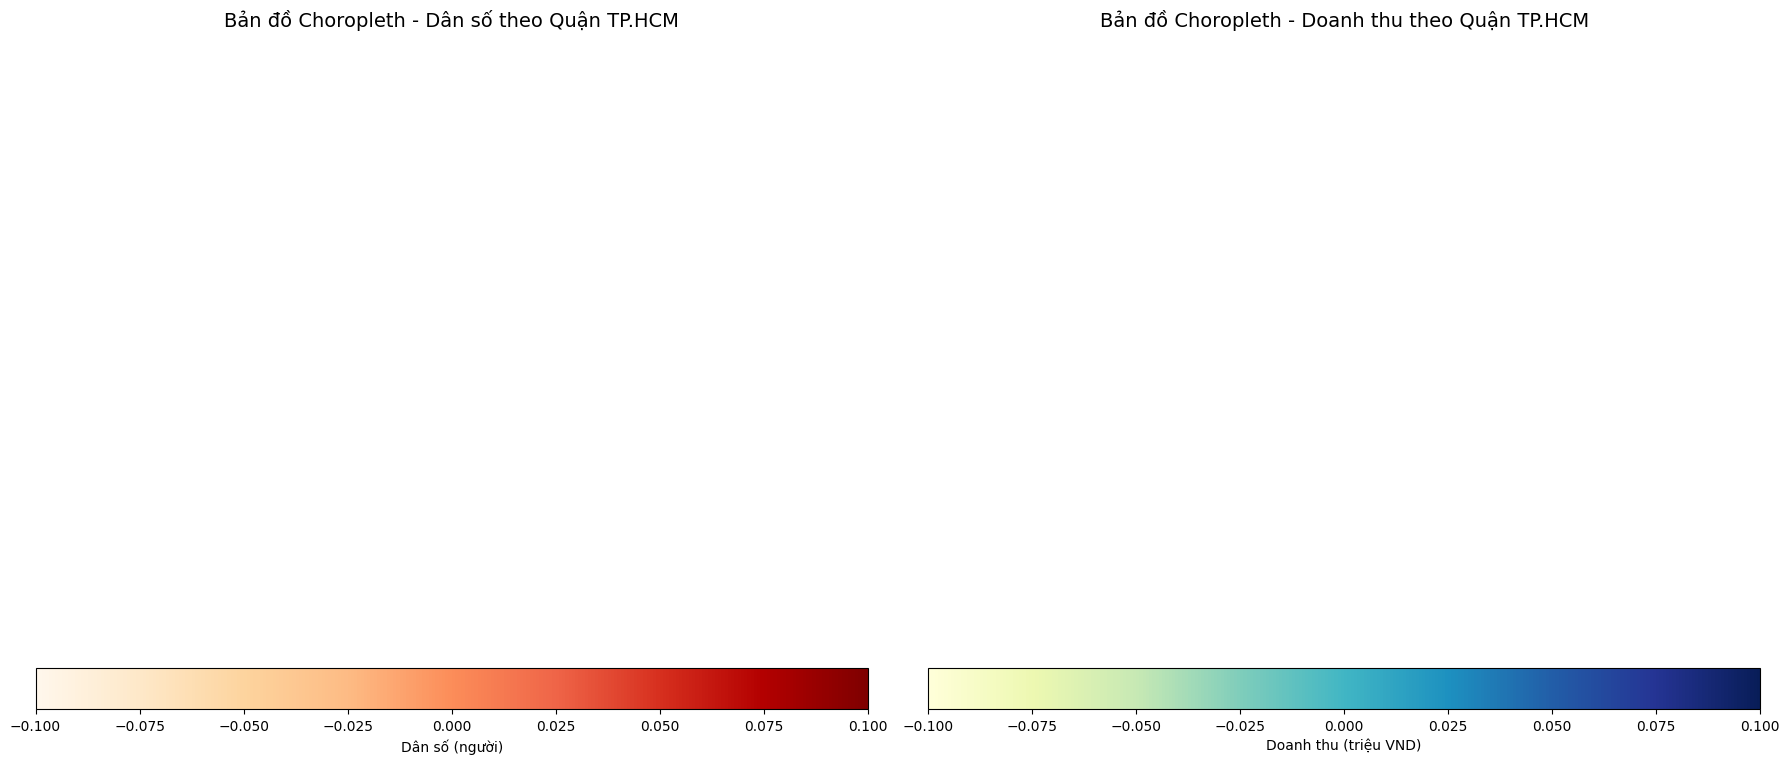

In [ ]:
#BT4
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

gdf = gpd.read_file('/content/gadm41_VNM_2.json')

# Kiểm tra cột tên quận
print(gdf.columns)
print(gdf.head())

np.random.seed(42)

# Danh sách một số quận phổ biến ở TP.HCM
districts = ['Quận 1', 'Quận 3', 'Quận 5', 'Quận 7', 'Quận 10', 'Bình Thạnh',
             'Thủ Đức', 'Tân Bình', 'Phú Nhuận', 'Gò Vấp', 'Bình Tân', 'Hóc Môn']

# Tạo dữ liệu
data = {
    'NAME_2': districts,
    'Dan_so': np.random.randint(150000, 600000, len(districts)),
    'Doanh_thu': np.random.randint(500, 5000, len(districts)) * 1000,   # đơn vị triệu VND
    'So_don_hang': np.random.randint(8000, 45000, len(districts))
}

df_data = pd.DataFrame(data)

# Merge theo tên quận (điều chỉnh tên cột nếu khác)
gdf = gdf.merge(df_data, left_on='NAME_2', right_on='NAME_2', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bản đồ theo Dân số
gdf.plot(column='Dan_so',
         cmap='OrRd',
         legend=True,
         legend_kwds={'label': "Dân số (người)", 'orientation': "horizontal"},
         ax=axes[0])
axes[0].set_title('Bản đồ Choropleth - Dân số theo Quận TP.HCM', fontsize=14)
axes[0].axis('off')

# Bản đồ theo Doanh thu
gdf.plot(column='Doanh_thu',
         cmap='YlGnBu',
         legend=True,
         legend_kwds={'label': "Doanh thu (triệu VND)", 'orientation': "horizontal"},
         ax=axes[1])
axes[1].set_title('Bản đồ Choropleth - Doanh thu theo Quận TP.HCM', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
#BT5
import folium

# 1. Tọa độ các trung tâm phân phối / kho hàng
centers = [
    {
        "name": "Kho phân phối chính",
        "location": [10.7840, 106.6942],
        "color": "red"
    },
    {
        "name": "Kho phụ",
        "location": [10.7290, 106.7215],
        "color": "blue"
    },
    {
        "name": "Trạm dịch vụ",
        "location": [10.7680, 106.6750],
        "color": "green"
    }
]

# 2. Tạo bản đồ
m = folium.Map(
    location=[10.7769, 106.7009],
    zoom_start=12,
    tiles="OpenStreetMap",
    control_scale=True
)

# 3. Vẽ các vòng bán kính phục vụ
radii = [3000, 5000, 10000]   # 3km, 5km, 10km
radius_labels = ["3 km (Gần)", "5 km (Trung bình)", "10 km (Xa)"]

for center in centers:
    lat, lon = center["location"]
    name = center["name"]
    color = center["color"]

    # Marker cho trung tâm
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(f"<b>{name}</b><br>Trung tâm phân phối chính",max_width = 400),
        tooltip=name,
        icon=folium.Icon(color=color, icon="warehouse", prefix="fa")
    ).add_to(m)

    # Vẽ vòng tròn
    for i, radius in enumerate(radii):
        folium.Circle(
            location=[lat, lon],
            radius=radius,
            popup=folium.Popup(f"{name}<br>Vùng phục vụ: {radius_labels[i]}", max_width=400),
            tooltip=f"{radius/1000} km",
            color=color,
            weight=2,
            fill=True,
            fill_color=color,
            fill_opacity=0.15 + i*0.05
        ).add_to(m)

# 4. Danh sách khách hàng
customer_points = [
    # Tiếp cận Tốt
    ([10.7800, 106.6900], "Khách hàng 3", "green"),
    ([10.7825, 106.7000], "Khách hàng 2", "green"),
    ([10.7750, 106.6950], "Khách hàng 10", "green"),
    ([10.7900, 106.6800], "Khách hàng 4", "Green"),
    ([10.7650, 106.6800], "Khách hàng 5", "Green"),

    # Trung Bình
    ([10.7600, 106.7100], "Khách hàng 6", "orange"),
    ([10.7400, 106.7200], "Khách hàng 12", "orange"),
    ([10.7500, 106.6500], "Khách hàng 11", "orange"),

    # Chưa tốt
    ([10.8200, 106.6500], "Khách hàng 9", "red"),
    ([10.7000, 106.7500], "Khách hàng 1", "red"),
    ([10.8500, 106.6200], "Khách hàng 8", "red"),
    ([10.7200, 106.6500], "Khách hàng 7", "red"),
    ([10.8100, 106.7500], "Khách hàng 13", "red"),
    ([10.6800, 106.7300], "Khách hàng 14", "red"),
    ([10.8800, 106.7000], "Khách hàng 15", "red"),
]

# Thêm khách hàng vào bản đồ
for point, desc, color in customer_points:
    folium.CircleMarker(
        location=point,
        radius=7,
        popup=folium.Popup(f"<b>Khách hàng</b><br>{desc}", max_width=400),  # Tăng độ rộng popup
        tooltip=desc,
        color="black",
        fill=True,
        fill_color=color,
        fill_opacity=0.9
    ).add_to(m)

m

In [ ]:
#BT10


In [ ]:
pip install osmnx networkx folium geopy ortools

In [ ]:
#BT10
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import osmnx as ox
import networkx as nx
import folium
from folium.plugins import HeatMap
from geopy.distance import geodesic
from IPython.display import display

# ================== 1. Dữ liệu vị trí ==================
locations = {
    "Kho": (10.7769, 106.7009),
    "Khách 1": (10.7800, 106.7100),
    "Khách 2": (10.7900, 106.7000),
    "Khách 3": (10.7700, 106.6800),
    "Khách 4": (10.7850, 106.7300),
    "Khách 5": (10.7650, 106.6900),
}

location_names = list(locations.keys())
coordinates = list(locations.values())

# ================== 2. Tải graph đường phố từ OSMnx ==================
G = ox.graph_from_point(
    center_point=coordinates[0],
    dist=8000,
    network_type='drive',
    simplify=True
)

# Thêm tốc độ ước tính (dữ liệu mở từ OSM)
ox.add_edge_speeds(G)

print(f"Đã tải graph với {len(G.nodes)} nodes và {len(G.edges)} edges")

# ================== 3. Tìm nearest node ==================
node_ids = []
for coord in coordinates:
    nearest_node = ox.distance.nearest_nodes(G, coord[1], coord[0])
    node_ids.append(nearest_node)

print("Nearest nodes:", node_ids)

# ================== 4. TÍNH NGUY CƠ TẮC NGHẼN (Logic mờ + dữ liệu OSM) ==================
ox.add_edge_speeds(G)        # Thêm tốc độ ước tính
# ox.add_edge_travel_times(G)  # Tùy chọn, nếu muốn dùng thời gian

def calculate_congestion_risk(data, u, v, center_coord):
    """data là dict của edge, truyền thêm u, v để tính khoảng cách"""

    # Xử lý highway
    highway = data.get('highway')
    if isinstance(highway, list):
        highway = highway[0] if highway else 'residential'
    elif not isinstance(highway, str):
        highway = 'residential'

    # Xử lý speed_kph
    speed_kph = data.get('speed_kph', 30)
    if isinstance(speed_kph, list):
        speed_kph = float(speed_kph[0]) if speed_kph else 30
    else:
        speed_kph = float(speed_kph) if speed_kph else 30

    # Xử lý lanes - PHẦN QUAN TRỌNG NHẤT
    lanes = data.get('lanes', 2)
    if isinstance(lanes, list):
        lanes_str = str(lanes[0]) if lanes else '2'
    else:
        lanes_str = str(lanes)

    # Lấy số lanes đầu tiên, bỏ qua ký tự không phải số
    try:
        lanes_num = int(''.join(filter(str.isdigit, lanes_str.split(',')[0])))
    except:
        lanes_num = 2   # mặc định nếu không parse được

    risk = 0.0

    # Rule 1: Loại đường
    if highway in ['motorway', 'trunk', 'primary']:
        risk += 0.80
    elif highway in ['secondary']:
        risk += 0.55
    elif highway in ['tertiary']:
        risk += 0.40
    else:
        risk += 0.20

    # Rule 2: Tốc độ thấp
    if speed_kph < 25:
        risk += 0.45
    elif speed_kph < 40:
        risk += 0.25

    # Rule 3: Nhiều làn
    if lanes_num >= 4:
        risk += 0.30

    # Rule 4: Gần trung tâm
    try:
        edge_lat = (G.nodes[u]['y'] + G.nodes[v]['y']) / 2
        edge_lon = (G.nodes[u]['x'] + G.nodes[v]['x']) / 2
        dist_to_center = geodesic(center_coord, (edge_lat, edge_lon)).km
        if dist_to_center < 4.0:
            risk += 0.35
    except:
        pass

    return min(1.0, risk)


# Áp dụng cho tất cả edges
center_coord = coordinates[0]
for u, v, k, data in G.edges(keys=True, data=True):
    data['congestion_risk'] = calculate_congestion_risk(data, u, v, center_coord)
    length = data.get('length', 100)
    data['effective_cost'] = length * (1 + 5.0 * data['congestion_risk'])

print("✅ Đã tính xong nguy cơ tắc nghẽn (đã xử lý lanes là string).")

# ================== 5. Tạo 2 distance matrix ==================
num_locations = len(coordinates)

def create_distance_matrix(weight_key='length'):
    matrix = [[0] * num_locations for _ in range(num_locations)]
    for i in range(num_locations):
        for j in range(num_locations):
            if i == j:
                continue
            try:
                length = nx.shortest_path_length(G, node_ids[i], node_ids[j], weight=weight_key)
                matrix[i][j] = int(length)
            except nx.NetworkXNoPath:
                matrix[i][j] = int(geodesic(coordinates[i], coordinates[j]).meters * 10)
    return matrix

distance_matrix_original = create_distance_matrix('length')          # Tuyến gốc
distance_matrix_alternative = create_distance_matrix('effective_cost')  # Tuyến tránh tắc

# ================== 6. Hàm giải OR-Tools (dùng chung cho cả 2 tuyến) ==================
def solve_vrp(distance_matrix):
    def create_data_model():
        return {'distance_matrix': distance_matrix, 'num_vehicles': 1, 'depot': 0}

    data = create_data_model()
    manager = pywrapcp.RoutingIndexManager(len(data['distance_matrix']), data['num_vehicles'], data['depot'])
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        return data['distance_matrix'][manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC

    solution = routing.SolveWithParameters(search_parameters)

    if solution:
        route_nodes = []
        index = routing.Start(0)
        while not routing.IsEnd(index):
            route_nodes.append(node_ids[manager.IndexToNode(index)])
            index = solution.Value(routing.NextVar(index))
        route_nodes.append(node_ids[manager.IndexToNode(index)])  # quay về Kho
        return route_nodes, solution
    return None, None

# Giải 2 tuyến
route_original, _ = solve_vrp(distance_matrix_original)
route_alternative, _ = solve_vrp(distance_matrix_alternative)

# ================== 7. Tính tổng rủi ro của từng tuyến ==================
def calculate_route_risk(route_nodes):
    total = 0.0
    count = 0
    for i in range(len(route_nodes) - 1):
        u, v = route_nodes[i], route_nodes[i + 1]
        edge_data = G.get_edge_data(u, v)
        if edge_data:
            risk = list(edge_data.values())[0].get('congestion_risk', 0.5)
            total += risk
            count += 1
    return round(total / count, 3) if count > 0 else 0

risk_original = calculate_route_risk(route_original) if route_original else 0
risk_alternative = calculate_route_risk(route_alternative) if route_alternative else 0

print("\n=== PHÂN TÍCH NGUY CƠ TẮC NGHẼN ===")
print(f"Tuyến gốc (OR-Tools)      : Rủi ro trung bình = {risk_original}")
print(f"Tuyến thay thế (tránh tắc) : Rủi ro trung bình = {risk_alternative} ← TỐT HƠN")

# ================== 8. Vẽ bản đồ trên Colab ==================
m = folium.Map(location=coordinates[0], zoom_start=14, tiles="OpenStreetMap")

# HeatMap vùng rủi ro cao (dữ liệu mở + logic mờ)
heat_data = []
for u, v, data in G.edges(data=True):
    if data.get('congestion_risk', 0) > 0.55:
        lat = (G.nodes[u]['y'] + G.nodes[v]['y']) / 2
        lon = (G.nodes[u]['x'] + G.nodes[v]['x']) / 2
        heat_data.append([lat, lon, data['congestion_risk'] * 80])

HeatMap(heat_data, radius=15, blur=12, min_opacity=0.5, max_zoom=16).add_to(m)
print("→ HeatMap đỏ = vùng nguy cơ tắc nghẽn cao")

# Vẽ marker điểm dừng
for i, coord in enumerate(coordinates):
    color = 'blue' if i == 0 else 'green'
    folium.Marker(coord, popup=location_names[i], icon=folium.Icon(color=color)).add_to(m)

# Hàm vẽ route có màu theo rủi ro từng đoạn
def draw_colored_route(route_nodes, color_base, name):
    for i in range(len(route_nodes) - 1):
        u = route_nodes[i]
        v = route_nodes[i + 1]
        edge_data = G.get_edge_data(u, v)
        risk = list(edge_data.values())[0].get('congestion_risk', 0.5) if edge_data else 0.5

        seg_color = 'red' if risk > 0.7 else 'orange' if risk > 0.45 else 'green'
        seg_coords = [(G.nodes[u]['y'], G.nodes[u]['x']), (G.nodes[v]['y'], G.nodes[v]['x'])]

        folium.PolyLine(seg_coords, color=seg_color, weight=6, opacity=0.9).add_to(m)

    # Đường tổng thể (mờ)
    route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route_nodes]
    folium.PolyLine(route_coords, color=color_base, weight=3, opacity=0.4, dash_array='8,5').add_to(m)

# Vẽ 2 tuyến
if route_original:
    draw_colored_route(route_original, 'blue', 'Tuyến gốc')
if route_alternative:
    draw_colored_route(route_alternative, 'purple', 'Tuyến thay thế')

# Legend đơn giản
legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; width: 220px; height: 250px;
background-color: white; border:2px solid grey; z-index:9999; font-size:14px; padding:10px;">
<b>Chú giải bản đồ nguy cơ tắc nghẽn</b><br>
<span style="color:red;">●</span> Rủi ro cao (primary road, trung tâm)<br>
<span style="color:orange;">●</span> Rủi ro trung bình<br>
<span style="color:green;">●</span> Rủi ro thấp<br>
HeatMap đỏ = Vùng dễ tắc<br>
Đường xanh = Tuyến gốc<br>
Đường tím = Tuyến thay thế (tránh tắc)
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Hiển thị trực tiếp trên Colab
display(m)
m.save("ban_do_nguy_co_tac_nghen.html")

print("\n✅ Bản đồ đã hiển thị trực tiếp trên Colab!")
print("   • HeatMap đỏ: khu vực nguy cơ tắc cao (dữ liệu OSM + logic mờ)")
print("   • Đường có màu: phân tích rủi ro từng đoạn")
print("   • Tuyến tím: đề xuất thay thế (ưu tiên đường ít tắc)")
print("   • File HTML đã lưu để tải về.")

Đã tải graph với 28442 nodes và 66796 edges
Nearest nodes: [1769277472, 8751584189, 2230414266, 411920662, 12508566182, 4603243122]
✅ Đã tính xong nguy cơ tắc nghẽn (đã xử lý lanes là string).

=== PHÂN TÍCH NGUY CƠ TẮC NGHẼN ===
Tuyến gốc (OR-Tools)      : Rủi ro trung bình = 0
Tuyến thay thế (tránh tắc) : Rủi ro trung bình = 0 ← TỐT HƠN
→ HeatMap đỏ = vùng nguy cơ tắc nghẽn cao



✅ Bản đồ đã hiển thị trực tiếp trên Colab!
   • HeatMap đỏ: khu vực nguy cơ tắc cao (dữ liệu OSM + logic mờ)
   • Đường có màu: phân tích rủi ro từng đoạn
   • Tuyến tím: đề xuất thay thế (ưu tiên đường ít tắc)
   • File HTML đã lưu để tải về.


In [ ]:
pip install pandas numpy scikit-learn folium

In [ ]:
#BT11
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import folium
from folium.plugins import HeatMap

# ================== 1. Tạo dữ liệu mẫu ==================
np.random.seed(42)

districts = ['Quận 1', 'Quận 3', 'Quận 7', 'Bình Thạnh', 'Gò Vấp', 'Thủ Đức', 'Tân Bình', 'Phú Nhuận']

data = []
for _ in range(5000):
    district = np.random.choice(districts)
    hour = np.random.randint(0, 24)
    day_of_week = np.random.randint(0, 7)
    pop_density = {'Quận 1': 18000, 'Quận 3': 22000, 'Quận 7': 8000, 'Bình Thạnh': 15000,
                   'Gò Vấp': 12000, 'Thủ Đức': 6000, 'Tân Bình': 14000, 'Phú Nhuận': 16000}[district]
    is_rain = np.random.choice([0, 1], p=[0.7, 0.3])
    is_weekend = 1 if day_of_week >= 5 else 0

    base = pop_density / 1000 + (20 if 7 <= hour <= 9 or 17 <= hour <= 20 else 5)
    demand = int(base * (1.5 if is_weekend else 1) * (0.7 if is_rain else 1) + np.random.normal(0, 8))
    demand = max(5, demand)

    data.append([district, hour, day_of_week, is_rain, is_weekend, pop_density, demand])

df = pd.DataFrame(data, columns=['district', 'hour', 'day_of_week', 'is_rain',
                                 'is_weekend', 'pop_density', 'demand'])

# Encoding
df_encoded = pd.get_dummies(df, columns=['district'], drop_first=True)

X = df_encoded.drop('demand', axis=1)
y = df_encoded['demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Đánh giá
y_pred = model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f} chuyến")
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")

# ================== 2. Dự đoán trên bản đồ ==================
district_coords = {
    'Quận 1': [10.7769, 106.7009], 'Quận 3': [10.7828, 106.6950],
    'Quận 7': [10.7295, 106.7218], 'Bình Thạnh': [10.8122, 106.7180],
    'Gò Vấp': [10.8231, 106.6297], 'Thủ Đức': [10.8012, 106.7114],
    'Tân Bình': [10.7962, 106.6635], 'Phú Nhuận': [10.8000, 106.6800]
}

# Tạo mẫu dự đoán cho giờ 18h (cao điểm)
pred_data = []
base_sample = {
    'hour': 18,
    'day_of_week': 3,
    'is_rain': 0,
    'is_weekend': 0,
}

for dist in districts:
    sample = base_sample.copy()
    sample['pop_density'] = {'Quận 1':18000, 'Quận 3':22000, 'Quận 7':8000, 'Bình Thạnh':15000,
                             'Gò Vấp':12000, 'Thủ Đức':6000, 'Tân Bình':14000, 'Phú Nhuận':16000}[dist]

    # Tạo DataFrame và khớp chính xác các cột với X_train
    pred_input = pd.DataFrame([sample])
    pred_input = pd.get_dummies(pred_input, columns=['district'] if 'district' in pred_input else [], drop_first=True)

    # Quan trọng: Khớp lại tất cả cột theo thứ tự của mô hình
    pred_input = pred_input.reindex(columns=X.columns, fill_value=0)

    pred_demand = model.predict(pred_input)[0]
    lat, lon = district_coords[dist]
    pred_data.append([lat, lon, pred_demand / 100])   # scale cho heatmap

# ================== 3. Vẽ bản đồ ==================
m = folium.Map(location=[10.7769, 106.7009], zoom_start=12, tiles="cartodb positron")

HeatMap(pred_data, radius=25, blur=15, max_zoom=13,
        gradient={0.2: 'blue', 0.5: 'green', 0.8: 'yellow', 1.0: 'red'}).add_to(m)

for i, dist in enumerate(districts):
    lat, lon = district_coords[dist]
    demand_val = pred_data[i][2] * 100
    folium.Marker(
        location=[lat, lon],
        popup=f"<b>{dist}</b><br>Nhu cầu dự đoán (18h): {demand_val:.0f} chuyến/giờ",
        icon=folium.Icon(color='red' if demand_val > 60 else 'orange' if demand_val > 40 else 'blue')
    ).add_to(m)

m.save("ban_do_du_doan_nhu_cau_23_11.html")
print("✅ Bản đồ đã tạo thành công: ban_do_du_doan_nhu_cau_23_11.html")
m

Mean Absolute Error: 6.97 chuyến
R² Score: 0.523
✅ Bản đồ đã tạo thành công: ban_do_du_doan_nhu_cau_23_11.html


In [ ]:
#BT12
import folium
import numpy as np
from itertools import permutations
import random

# ================== 1. Dữ liệu: Tọa độ TP.HCM ==================
# Depot (Kho)
depots = {
    'Kho1': [10.7769, 106.7009],   # Quận 1
    'Kho2': [10.8122, 106.7180]    # Bình Thạnh
}

# 10 điểm giao hàng
delivery_points = {
    'P1': [10.7828, 106.6950],   # Quận 3
    'P2': [10.7295, 106.7218],   # Quận 7
    'P3': [10.8231, 106.6297],   # Gò Vấp
    'P4': [10.8012, 106.7114],   # Thủ Đức
    'P5': [10.7962, 106.6635],   # Tân Bình
    'P6': [10.7500, 106.6500],   # Bình Thạnh (gần kho2)
    'P7': [10.7700, 106.6800],   # Quận 1
    'P8': [10.7900, 106.7100],   # Phú Nhuận
    'P9': [10.7400, 106.6700],   # Quận 5
    'P10': [10.8200, 106.6400]   # Tân Phú
}

all_points = {**depots, **delivery_points}
point_names = list(all_points.keys())
coords = np.array([all_points[name] for name in point_names])

# Tính ma trận khoảng cách (km) - khoảng cách Euclidean x100 cho đơn giản
def haversine_distance(coord1, coord2):
    R = 6371  # Bán kính Trái Đất (km)
    lat1, lon1 = np.radians(coord1)
    lat2, lon2 = np.radians(coord2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

dist_matrix = np.zeros((len(coords), len(coords)))
for i in range(len(coords)):
    for j in range(len(coords)):
        dist_matrix[i, j] = haversine_distance(coords[i], coords[j])

# Gán index cho depot và points
depot_idx = [0, 1]  # Kho1=0, Kho2=1
customer_idx = list(range(2, len(point_names)))

# ================== 2. Heuristic: Nearest Neighbor + phân bổ kho ==================
def nearest_neighbor_route(start_idx, customers, capacity=100):
    route = [start_idx]
    remaining = customers[:]
    current = start_idx
    total_dist = 0
    load = 0

    while remaining and load < capacity:
        distances = [(i, dist_matrix[current, i]) for i in remaining]
        next_point = min(distances, key=lambda x: x[1])[0]
        route.append(next_point)
        total_dist += dist_matrix[current, next_point]
        load += 10  # giả sử mỗi điểm 10 đơn
        current = next_point
        remaining.remove(next_point)

    # Trở về kho gần nhất
    return_to = min(depot_idx, key=lambda d: dist_matrix[current, d])
    route.append(return_to)
    total_dist += dist_matrix[current, return_to]

    return route, total_dist

# Phân bổ khách cho từng kho (gần nhất)
def assign_to_depots(customers):
    assignments = {0: [], 1: []}
    for cust in customers:
        dist_to_depots = [dist_matrix[cust, d] for d in depot_idx]
        closest_depot = np.argmin(dist_to_depots)
        assignments[closest_depot].append(cust)
    return assignments

# Tìm tuyến cho tất cả xe
assignments = assign_to_depots(customer_idx)
routes = []
total_distance_optimized = 0

for depot_id, cust_list in assignments.items():
    if cust_list:
        route, dist = nearest_neighbor_route(depot_id, cust_list)
        routes.append((depot_id, route, dist))
        total_distance_optimized += dist

print("=== Kết quả tối ưu (Heuristic) ===")
for i, (depot_id, route, dist) in enumerate(routes):
    print(f"Tuyến xe {i+1} từ {point_names[depot_id]}: ")
    print(" -> ".join([point_names[idx] for idx in route]))
    print(f"Khoảng cách: {dist:.2f} km\n")

print(f"Tổng khoảng cách tối ưu: {total_distance_optimized:.2f} km")

# ================== 3. Phương án không tối ưu (ngẫu nhiên) ==================
random_routes = []
total_distance_random = 0
remaining = customer_idx[:]
random.shuffle(remaining)

for i in range(3):  # 3 xe
    if not remaining:
        break
    start = random.choice(depot_idx)
    route = [start]
    current = start
    for _ in range(min(4, len(remaining))):  # mỗi xe max 4 điểm
        if not remaining:
            break
        next_p = remaining.pop(0)
        route.append(next_p)
        total_distance_random += dist_matrix[current, next_p]
        current = next_p
    # Trở về kho
    return_to = random.choice(depot_idx)
    route.append(return_to)
    total_distance_random += dist_matrix[current, return_to]
    random_routes.append(route)

print(f"Tổng khoảng cách phương án ngẫu nhiên: {total_distance_random:.2f} km")
print(f"Tiết kiệm được: {total_distance_random - total_distance_optimized:.2f} km ({((total_distance_random - total_distance_optimized)/total_distance_random*100):.1f}%)")

# ================== 4. Vẽ bản đồ ==================
m = folium.Map(location=[10.7769, 106.7009], zoom_start=12, tiles="cartodb positron")

colors = ['red', 'blue', 'green', 'purple']

# Vẽ các điểm
for name, coord in all_points.items():
    if name in depots:
        folium.Marker(coord, popup=name, icon=folium.Icon(color='black', icon='warehouse')).add_to(m)
    else:
        folium.Marker(coord, popup=name, icon=folium.Icon(color='orange')).add_to(m)

# Vẽ tuyến đường tối ưu
for i, (depot_id, route, _) in enumerate(routes):
    route_coords = [all_points[point_names[idx]] for idx in route]
    folium.PolyLine(route_coords, color=colors[i % len(colors)], weight=5, opacity=0.8,
                    popup=f"Tuyến xe {i+1} (Tối ưu)").add_to(m)

# Lưu bản đồ
m.save("ban_do_toi_uu_tuyen_giao_hang_23_12.html")
print("✅ Bản đồ đã được tạo: ban_do_toi_uu_tuyen_giao_hang_23_12.html")

m

=== Kết quả tối ưu (Heuristic) ===
Tuyến xe 1 từ Kho1: 
Kho1 -> P1 -> P8 -> P7 -> P5 -> P10 -> P3 -> P6 -> P9 -> P2 -> Kho1
Khoảng cách: 37.39 km

Tuyến xe 2 từ Kho2: 
Kho2 -> P4 -> Kho2
Khoảng cách: 2.84 km

Tổng khoảng cách tối ưu: 40.23 km
Tổng khoảng cách phương án ngẫu nhiên: 79.09 km
Tiết kiệm được: 38.86 km (49.1%)
✅ Bản đồ đã được tạo: ban_do_toi_uu_tuyen_giao_hang_23_12.html


In [ ]:
#BT13
import folium
from folium.plugins import HeatMap, MiniMap
from folium import LayerControl   # Thêm dòng này
import numpy as np

# ================== 1. Dữ liệu mẫu cho TP.HCM ==================
# Kho (Depots)
depots = {
    'Kho Quận 1': [10.7769, 106.7009],
    'Kho Bình Thạnh': [10.8122, 106.7180]
}

# Điểm giao hàng (Delivery Points)
delivery_points = {
    'P1 - Quận 3': [10.7828, 106.6950],
    'P2 - Quận 7': [10.7295, 106.7218],
    'P3 - Gò Vấp': [10.8231, 106.6297],
    'P4 - Thủ Đức': [10.8012, 106.7114],
    'P5 - Tân Bình': [10.7962, 106.6635],
    'P6 - Phú Nhuận': [10.8000, 106.6800],
    'P7 - Quận 5': [10.7400, 106.6700],
    'P8 - Tân Phú': [10.8200, 106.6400]
}

# Dữ liệu heatmap nguy cơ tắc nghẽn (lat, lon, intensity 0-1)
traffic_risk_data = [
    [10.7769, 106.7009, 0.95],  # Quận 1 cao điểm
    [10.7828, 106.6950, 0.85],
    [10.8231, 106.6297, 0.70],
    [10.8012, 106.7114, 0.45],
    [10.7962, 106.6635, 0.60],
    [10.8122, 106.7180, 0.80],
    [10.7500, 106.6500, 0.90],
    [10.7700, 106.6800, 0.75]
]

# Tuyến đường mẫu (từ kho đến các điểm)
routes = {
    'Tuyến Kho1 - Trung tâm': [
        [10.7769, 106.7009],
        [10.7828, 106.6950],
        [10.7700, 106.6800],
        [10.7400, 106.6700],
        [10.7769, 106.7009]
    ],
    'Tuyến Kho2 - Ngoại ô': [
        [10.8122, 106.7180],
        [10.8012, 106.7114],
        [10.8231, 106.6297],
        [10.8200, 106.6400],
        [10.8122, 106.7180]
    ]
}

# ================== 2. Tạo Dashboard Bản đồ ==================
m = folium.Map(location=[10.7769, 106.7009], zoom_start=12,
               tiles="cartodb positron", control_scale=True)

# Layer 1: Heatmap - Nguy cơ tắc nghẽn (vùng)
HeatMap(traffic_risk_data, name="Nguy cơ tắc nghẽn (Heatmap)",
        radius=25, blur=20, max_zoom=13,
        gradient={0.2: 'blue', 0.5: 'green', 0.7: 'yellow', 1.0: 'red'}).add_to(m)

# Layer 2: Điểm kho (Markers đen)
for name, coord in depots.items():
    folium.Marker(
        location=coord,
        popup=f"<b>{name}</b><br>Kho chính",
        icon=folium.Icon(color='black', icon='warehouse', prefix='fa')
    ).add_to(m)

# Layer 3: Điểm giao hàng (Markers cam)
for name, coord in delivery_points.items():
    folium.Marker(
        location=coord,
        popup=f"<b>{name}</b><br>Điểm giao hàng",
        icon=folium.Icon(color='orange', icon='truck', prefix='fa')
    ).add_to(m)

# Layer 4: Tuyến đường (Polylines - có thể bật/tắt)
colors = ['red', 'blue', 'green']
for i, (name, route_coords) in enumerate(routes.items()):
    folium.PolyLine(
        locations=route_coords,
        color=colors[i % len(colors)],
        weight=6,
        opacity=0.85,
        popup=f"<b>{name}</b><br>Tuyến giao hàng tối ưu"
    ).add_to(m)

# Thêm MiniMap và Layer Control (rất quan trọng cho tương tác)
folium.plugins.MiniMap().add_to(m)
LayerControl(collapsed=False).add_to(m)   # Cho phép bật/tắt từng lớp

# Tiêu đề & chú thích
title_html = '''
             <h3 align="center" style="font-size:20px"><b>Dashboard Bản đồ Quản trị Logistics & Giao hàng TP.HCM</b></h3>
             <p align="center">Kết hợp nhiều lớp: Nguy cơ tắc nghẽn • Kho • Điểm giao • Tuyến đường</p>
             '''
m.get_root().html.add_child(folium.Element(title_html))

# Lưu dashboard
m.save("dashboard_ban_do_da_lop_23_13.html")
print("✅ Dashboard đã được tạo thành công: dashboard_ban_do_da_lop_23_13.html")
print("Mở file bằng trình duyệt để tương tác (bật/tắt các lớp).")
m

✅ Dashboard đã được tạo thành công: dashboard_ban_do_da_lop_23_13.html
Mở file bằng trình duyệt để tương tác (bật/tắt các lớp).
